In [9]:
%matplotlib inline
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.api as sm
from statsmodels.tsa.stattools import adfuller, coint
from statsmodels.tsa.vector_ar.var_model import VAR
from statsmodels.tsa.vector_ar.vecm import VECM
import yfinance as yf

# Set plot style
plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')

def plot_series(series1, series2, title="Time Series Plot"):
    """
    Plots two time series on a single formatted graph.
    """
    plt.figure(figsize=(12, 5))
    plt.plot(series1.index, series1, label=series1.name, lw=1.5)
    plt.plot(series2.index, series2, label=series2.name, lw=1.5)
    plt.title(title, fontsize=14, fontweight='bold')
    plt.xlabel('Date')
    plt.ylabel('Value')
    plt.legend(loc='best')
    plt.tight_layout()
    plt.show()

def check_stationarity(series, p_threshold=0.05):
    """
    Returns True if the series is stationary (p-value < p_threshold),
    False otherwise.
    """
    clean_series = series.dropna()
    result = adfuller(clean_series)
    return result[1] < p_threshold

def check_cointegration(series1, series2, p_threshold=0.05):
    """
    Returns True if series1 and series2 are cointegrated.
    """
    df = pd.concat([series1, series2], axis=1).dropna()
    score, p_value, _ = coint(df.iloc[:, 0], df.iloc[:, 1])
    return p_value < p_threshold

In [10]:
def load_data(source="yfinance", tickers=['AAPL', 'MSFT'], csv_path=None, start="2021-01-01", end="2023-01-01"):
    """
    Loads price data from yfinance or a local CSV file.
    """
    if source == "yfinance":
        print(f"Fetching data from yfinance for tickers: {tickers}...")
        df = yf.download(tickers, start=start, end=end, auto_adjust=False)
        
        if 'Adj Close' in df.columns.levels[0]:
            prices = df['Adj Close']
        elif 'Close' in df.columns.levels[0]:
            prices = df['Close']
        else:
            prices = df
            
        prices = prices.dropna()
        return prices[tickers[0]], prices[tickers[1]]
    
    elif source == "csv":
        print(f"Loading data from CSV file: {csv_path}...")
        df = pd.read_csv(csv_path, parse_dates=True, index_col=0)
        df = df.dropna()
        col1, col2 = df.columns[0], df.columns[1]
        return df[col1], df[col2]
    
    else:
        raise ValueError("source must be either 'yfinance' or 'csv'")

# Load data
series1, series2 = load_data(source="yfinance", tickers=['AAPL', 'MSFT'], start="2021-01-01", end="2023-01-01")

[*********************100%***********************]  2 of 2 completed

Fetching data from yfinance for tickers: ['AAPL', 'MSFT']...


In [11]:
def run_timeseries_workflow(s1, s2, alpha=0.05):
    """
    Executes decision workflow and produces visual plots at each step.
    """
    # 0. Initial Plot
    plot_series(s1, s2, title="Initial Time Series Data")

    # 1. Check stationarity for both series
    stat1 = check_stationarity(s1, p_threshold=alpha)
    stat2 = check_stationarity(s2, p_threshold=alpha)
    
    print("=" * 60)
    print(f"Stationarity Test Results (alpha={alpha}):")
    print(f"  - Series 1 ({s1.name}): {'Stationary' if stat1 else 'Non-Stationary'}")
    print(f"  - Series 2 ({s2.name}): {'Stationary' if stat2 else 'Non-Stationary'}")
    print("=" * 60)

    # -------------------------------------------------------------
    # Case A: Both time series are stationary
    # -------------------------------------------------------------
    if stat1 and stat2:
        print("\n[Case A] Both time series are stationary -> Running OLS & VAR models.")
        
        # OLS & Residual Plot
        X = sm.add_constant(s1)
        ols_model = sm.OLS(s2, X).fit()
        print("\n--- OLS Regression Summary ---")
        print(ols_model.summary())
        
        plt.figure(figsize=(10, 4))
        plt.plot(ols_model.resid, label='OLS Residuals', color='purple')
        plt.axhline(0, color='black', linestyle='--', alpha=0.7)
        plt.title("Case A: OLS Model Residuals")
        plt.legend()
        plt.tight_layout()
        plt.show()

        # VAR Model
        var_data = pd.concat([s1, s2], axis=1).dropna()
        var_model = VAR(var_data).fit(maxlags=5)
        print("\n--- VAR Model Summary ---")
        print(var_model.summary())
        return {"case": "a", "ols": ols_model, "var": var_model}

    # -------------------------------------------------------------
    # Case B: Both time series are NOT stationary
    # -------------------------------------------------------------
    elif not stat1 and not stat2:
        print("\n[Case B] Both time series are non-stationary.")
        
        cointegrated = check_cointegration(s1, s2, p_threshold=alpha)
        print(f"  - Cointegration Test Result: {'Cointegrated' if cointegrated else 'Not Cointegrated'}")
        
        if cointegrated:
            print("\n--> Cointegrated: Running Vector Error Correction Model (VECM / ECM)...")
            vecm_data = pd.concat([s1, s2], axis=1).dropna()
            vecm_model = VECM(vecm_data, k_ar_diff=1, coint_rank=1).fit()
            print("\n--- VECM (Error Correction Model) Summary ---")
            print(vecm_model.summary())
            
            # Cointegrating Vector / Spread Plot
            # Estimate spread using OLS for visual representation
            X = sm.add_constant(s1)
            ols_temp = sm.OLS(s2, X).fit()
            spread = ols_temp.resid
            
            plt.figure(figsize=(12, 4))
            plt.plot(spread, color='darkgreen', label='Cointegrating Spread (Residuals)')
            plt.axhline(0, color='red', linestyle='--')
            plt.title("Case B: Cointegrating Spread (Stationary Residual Series)")
            plt.legend()
            plt.tight_layout()
            plt.show()
            
            return {"case": "b_cointegrated", "vecm": vecm_model}
            
        else:
            print("\n--> Not Cointegrated: Taking first differences of non-stationary series...")
            diff1 = s1.diff().dropna()
            diff2 = s2.diff().dropna()
            
            # Plot differenced series
            plot_series(diff1, diff2, title="Case B: First-Differenced Series Plot")
            
            diff1_stat = check_stationarity(diff1, p_threshold=alpha)
            diff2_stat = check_stationarity(diff2, p_threshold=alpha)
            
            print(f"  - First Diff Series 1 ({s1.name}): {'Stationary' if diff1_stat else 'Non-Stationary'}")
            print(f"  - First Diff Series 2 ({s2.name}): {'Stationary' if diff2_stat else 'Non-Stationary'}")
            
            if diff1_stat and diff2_stat:
                print("--> Both differenced series are stationary. Running OLS regression.")
                X = sm.add_constant(diff1)
                ols_model = sm.OLS(diff2, X).fit()
                print("\n--- Differenced OLS Regression Summary ---")
                print(ols_model.summary())
                
                # Residuals plot for differenced OLS
                plt.figure(figsize=(10, 4))
                plt.plot(ols_model.resid, label='Differenced OLS Residuals', color='teal')
                plt.axhline(0, color='black', linestyle='--', alpha=0.7)
                plt.title("Case B: Differenced OLS Residuals")
                plt.legend()
                plt.tight_layout()
                plt.show()
                
                return {"case": "b_not_cointegrated", "ols": ols_model}
            else:
                print("--> Warning: Differenced series are still not stationary. Higher-order differencing needed.")
                return {"case": "b_not_cointegrated_failed"}

    # -------------------------------------------------------------
    # Case C: One time series is non-stationary and the other is stationary
    # -------------------------------------------------------------
    else:
        print("\n[Case C] One series is stationary and the other is non-stationary.")
        
        if not stat1:
            print(f"--> Differencing non-stationary series: {s1.name}")
            s1_transformed = s1.diff().dropna()
            s2_transformed = s2.loc[s1_transformed.index]
        else:
            print(f"--> Differencing non-stationary series: {s2.name}")
            s2_transformed = s2.diff().dropna()
            s1_transformed = s1.loc[s2_transformed.index]
            
        # Plot transformed series
        plot_series(s1_transformed, s2_transformed, title="Case C: Transformed Stationary Series")
        
        check_trans1 = check_stationarity(s1_transformed, p_threshold=alpha)
        check_trans2 = check_stationarity(s2_transformed, p_threshold=alpha)
        
        if check_trans1 and check_trans2:
            print("--> Both transformed series are now stationary. Running OLS regression.")
            X = sm.add_constant(s1_transformed)
            ols_model = sm.OLS(s2_transformed, X).fit()
            print("\n--- OLS Regression Summary ---")
            print(ols_model.summary())
            
            # Residual plot
            plt.figure(figsize=(10, 4))
            plt.plot(ols_model.resid, label='Transformed OLS Residuals', color='orange')
            plt.axhline(0, color='black', linestyle='--', alpha=0.7)
            plt.title("Case C: Transformed OLS Residuals")
            plt.legend()
            plt.tight_layout()
            plt.show()
            
            return {"case": "c", "ols": ols_model}
        else:
            print("--> Warning: Transformed series are still not stationary.")
            return {"case": "c_failed"}

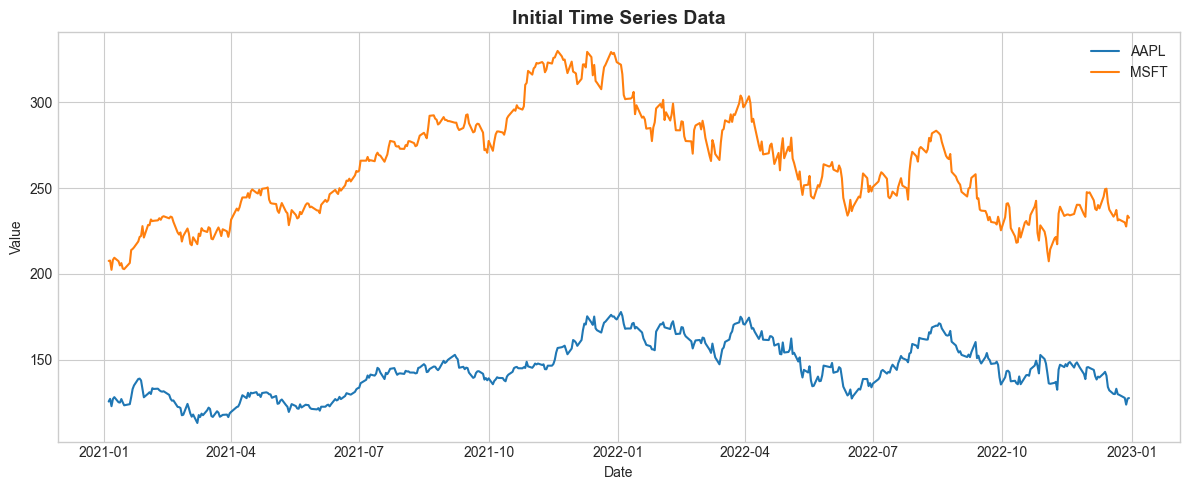

Stationarity Test Results (alpha=0.05):
  - Series 1 (AAPL): Non-Stationary
  - Series 2 (MSFT): Non-Stationary

[Case B] Both time series are non-stationary.
  - Cointegration Test Result: Not Cointegrated

--> Not Cointegrated: Taking first differences of non-stationary series...


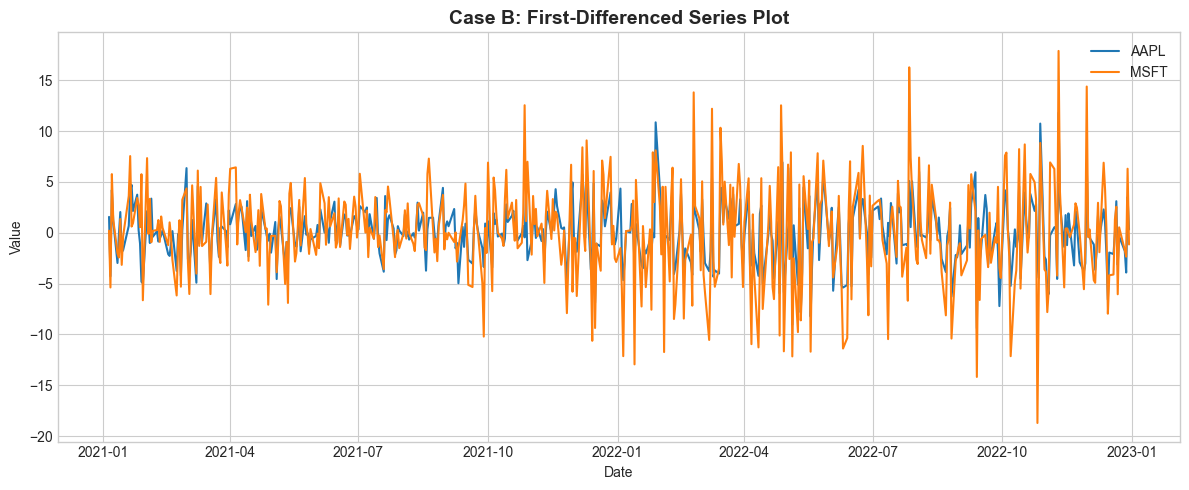

  - First Diff Series 1 (AAPL): Stationary
  - First Diff Series 2 (MSFT): Stationary
--> Both differenced series are stationary. Running OLS regression.

--- Differenced OLS Regression Summary ---
                            OLS Regression Results                            
Dep. Variable:                   MSFT   R-squared:                       0.601
Model:                            OLS   Adj. R-squared:                  0.600
Method:                 Least Squares   F-statistic:                     753.2
Date:                Thu, 24 Sep 2026   Prob (F-statistic):          7.90e-102
Time:                        16:05:34   Log-Likelihood:                -1261.6
No. Observations:                 502   AIC:                             2527.
Df Residuals:                     500   BIC:                             2536.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
            

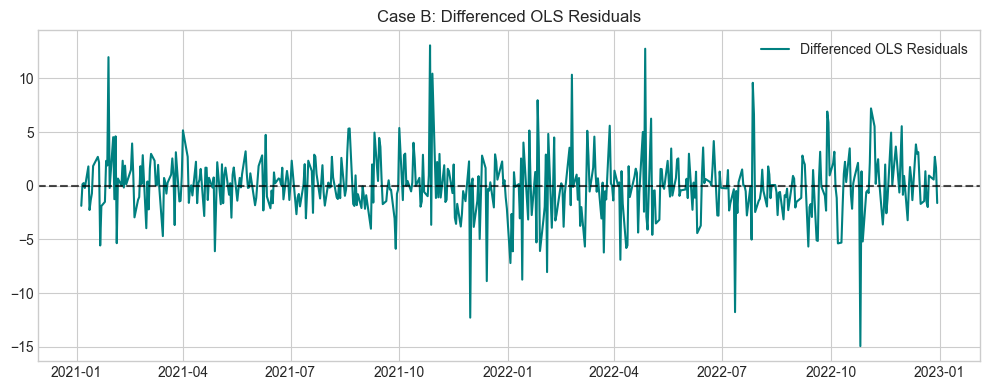

In [12]:
# Execute workflow
results = run_timeseries_workflow(series1, series2)

In [13]:
# Check which case was executed
print("Executed Workflow Case:", results.get("case"))

# Check if OLS model summary is present
if "ols" in results:
    print("\nYes, OLS regression was executed!")
    print(results["ols"].summary())
else:
    print("\nNo, OLS was not executed (VECM / ECM was used instead).")

Executed Workflow Case: b_not_cointegrated

Yes, OLS regression was executed!
                            OLS Regression Results                            
Dep. Variable:                   MSFT   R-squared:                       0.601
Model:                            OLS   Adj. R-squared:                  0.600
Method:                 Least Squares   F-statistic:                     753.2
Date:                Thu, 24 Sep 2026   Prob (F-statistic):          7.90e-102
Time:                        16:07:35   Log-Likelihood:                -1261.6
No. Observations:                 502   AIC:                             2527.
Df Residuals:                     500   BIC:                             2536.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------